<a href="https://colab.research.google.com/github/Wish245/troubleshoot_agents/blob/main/mushroom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('mushrooms.csv')

# Explore the dataset
print(df.head())
print(df.info())

FileNotFoundError: [Errno 2] No such file or directory: 'mushrooms.csv'

### Loading data from Google Drive

To load a file from Google Drive, you first need to mount your Google Drive to your Colab runtime. This will allow your notebook to access files stored in your Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

# IMPORTANT: Replace 'path/to/your/mushrooms.csv' with the actual path to your file in Google Drive
# Example: df = pd.read_csv('/content/drive/MyDrive/mushrooms.csv')
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/mushrooms.csv' # <<<--- UPDATE THIS PATH

try:
    df = pd.read_csv(drive_file_path)
    print("Dataset loaded successfully from Google Drive.")
    print(df.head())
    print(df.info())
except FileNotFoundError:
    print(f"Error: The file '{drive_file_path}' was not found in your Google Drive. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Dataset loaded successfully from Google Drive.
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w         

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd # Ensure pandas is imported if not already

# The original mushrooms dataset might contain '?' as a missing value for 'stalk-root'
# We'll replace these with NaN first, and then handle them if necessary.
# However, based on the df.info(), pandas currently treats '?' as a category, not NaN.
# Since all columns are categorical, df.median() is not appropriate.
# We will proceed with one-hot encoding.

# Identify the target variable (label) for the mushrooms dataset, which is 'class'
y = df['class']
X = df.drop('class', axis=1)

# Convert categorical features into numerical using one-hot encoding
# This creates new columns for each category, which are numerical (0 or 1).
X = pd.get_dummies(X)

# Now, split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Features (X) head after one-hot encoding:")
print(X.head())
print("Target (y) head:")
print(y.head())
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features (X) head after one-hot encoding:
   cap-shape_b  cap-shape_c  cap-shape_f  cap-shape_k  cap-shape_s  \
0        False        False        False        False        False   
1        False        False        False        False        False   
2         True        False        False        False        False   
3        False        False        False        False        False   
4        False        False        False        False        False   

   cap-shape_x  cap-surface_f  cap-surface_g  cap-surface_s  cap-surface_y  \
0         True          False          False           True          False   
1         True          False          False           True          False   
2        False          False          False           True          False   
3         True          False          False          False           True   
4         True          False          False           True          False   

   ...  population_s  population_v  population_y  habitat_d  habitat

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 100.00%


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Train decision tree model
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree.predict(X_test)

# Evaluate the model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree * 100:.2f}%")

Decision Tree Accuracy: 100.00%


In [9]:
from sklearn.svm import SVC

# Train SVM model
svm = SVC()
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")

SVM Accuracy: 100.00%


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate Logistic Regression model
precision_lr = precision_score(y_test, y_pred, average='weighted')
recall_lr = recall_score(y_test, y_pred, average='weighted')
f1_lr = f1_score(y_test, y_pred, average='weighted')

print(f"\nLogistic Regression - Precision: {precision_lr:.2f}, Recall: {recall_lr:.2f}, F1 Score: {f1_lr:.2f}")

# Evaluate Decision Tree model
precision_tree = precision_score(y_test, y_pred_tree, average='weighted')
recall_tree = recall_score(y_test, y_pred_tree, average='weighted')
f1_tree = f1_score(y_test, y_pred_tree, average='weighted')

print(f"Decision Tree - Precision: {precision_tree:.2f}, Recall: {recall_tree:.2f}, F1 Score: {f1_tree:.2f}")

# Evaluate SVM model
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

print(f"SVM - Precision: {precision_svm:.2f}, Recall: {recall_svm:.2f}, F1 Score: {f1_svm:.2f}")


Logistic Regression - Precision: 1.00, Recall: 1.00, F1 Score: 1.00
Decision Tree - Precision: 1.00, Recall: 1.00, F1 Score: 1.00
SVM - Precision: 1.00, Recall: 1.00, F1 Score: 1.00


/tmp/ipykernel_1085/3906385219.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')


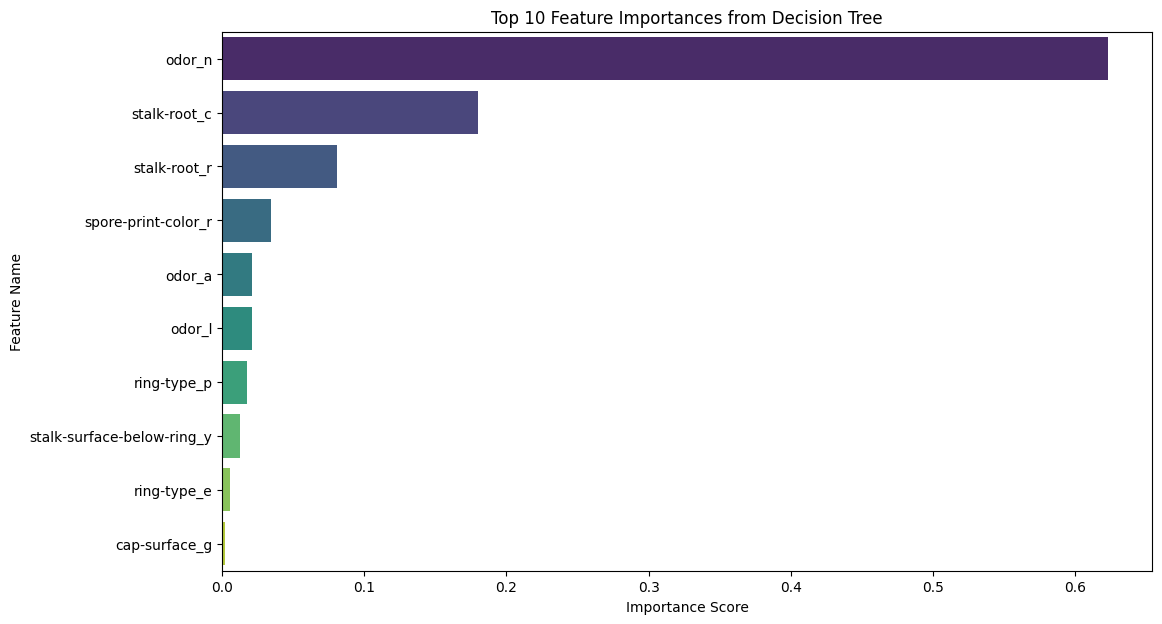

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Decision Tree model
feature_importances = tree.feature_importances_

# Get feature names from the one-hot encoded DataFrame X
feature_names = X.columns

# Create a pandas Series for easier handling and sorting
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort the features by importance in descending order and select the top 10
top_10_features = importance_df.nlargest(10)

# Plot the top 10 feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis')
plt.title('Top 10 Feature Importances from Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()